<a href="https://colab.research.google.com/github/DARIOYBETY123/Modulo5/blob/main/lab_c_embedding_ops_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1 · Embeddings — In-class Lab C 🧪
## Use the vectors: neighbours, analogies, t-SNE

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/01-embeddings/labs/in-class/lab-c-embedding-ops.ipynb)

This is **Mini-lab C**, split out from the combined in-class lab. It pairs with **Lesson 3** (embedding operations).

### How this lab works

**The machinery is given to you.** Lab B's whole pipeline is re-run for you below (nothing to fill in), pretrained GloVe is loaded, and cosine similarity, nearest-neighbour search, analogy solving and the t-SNE plot are all written and ready.

**What you write is the investigation.** Sections 🔬 **E5** and 🔬 **E6** ask you to *evaluate* these vectors instead of admiring them: build your own benchmark and measure whether cosine really captures meaning, then measure how often the famous `king − man + woman ≈ queen` trick actually works when you stop cherry-picking.

Treat everything above the 🔬 sections as your **sandbox**: read it, run it, then take it apart.

Runs on CPU; the one-time GloVe download (~66 MB) dominates the first run.


In [1]:
# Setup — run me first (works on Colab AND locally)
# On Colab this installs the few extra libraries; locally the course venv
# (.venv, environment/requirements.txt) already has everything.
import sys

if "google.colab" in sys.modules:
    %pip install -q datasets gensim scikit-learn

print("Setup OK — running on", "Colab" if "google.colab" in sys.modules else "local Python")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 29.5 MB/s eta 0:00:00
Setup OK — running on Colab


In [2]:
# Imports + seeds — fixed seeds make every run (and every student) identical
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

print("torch", torch.__version__)

torch 2.11.0+cpu


## 1 · Prerequisite (provided) — the tiny word2vec from Lab B

So this notebook stands alone, the next two cells rebuild Lab B's model end to end: corpus → vocabulary → skip-gram pairs → negative-sampling training → the embedding matrix $E$. **Nothing to fill in** — run them and move on.

In [3]:
# Corpus + vocabulary (Lab B, provided)
from datasets import load_dataset

ds = load_dataset("fancyzhx/ag_news", split="train").select(range(2000))
corpus = [t.lower() for t in ds["text"]]

V = 2000
counts = Counter(w for t in corpus for w in t.split())
vocab = [w for w, _ in counts.most_common(V)]
word2id = {w: i for i, w in enumerate(vocab)}
id2word = vocab
ids_corpus = [[word2id[w] for w in t.split() if w in word2id] for t in corpus]

print(f"{len(corpus)} texts, vocab {len(vocab)} words, "
      f"{sum(len(s) for s in ids_corpus):,} tokens kept")

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

2000 texts, vocab 2000 words, 57,687 tokens kept


In [4]:
# Train Lab B's skip-gram (provided — identical code, condensed)
class SkipGram(nn.Module):
    def __init__(self, V, d):
        super().__init__()
        self.in_embed = nn.Embedding(V, d)    # E — the prize
        self.out_embed = nn.Embedding(V, d)   # U — scaffolding
        nn.init.uniform_(self.in_embed.weight, -0.5 / d, 0.5 / d)
        nn.init.uniform_(self.out_embed.weight, -0.5 / d, 0.5 / d)


C, d, k_neg = 2, 50, 5
centers, contexts = [], []
for s in ids_corpus:
    for i, c in enumerate(s):
        for j in range(max(0, i - C), min(len(s), i + C + 1)):
            if j != i:
                centers.append(c)
                contexts.append(s[j])
centers, contexts = torch.tensor(centers), torch.tensor(contexts)

freqs = torch.tensor([counts[w] for w in vocab], dtype=torch.float) ** 0.75
noise = freqs / freqs.sum()

torch.manual_seed(0)
np.random.seed(0)
model = SkipGram(V, d)
opt = torch.optim.Adam(model.parameters(), lr=5e-3)

for epoch in range(5):
    perm = torch.randperm(len(centers))
    for start in range(0, len(centers), 1024):
        idx = perm[start : start + 1024]
        v_w = model.in_embed(centers[idx])
        u_o = model.out_embed(contexts[idx])
        neg_ids = torch.multinomial(noise, len(idx) * k_neg, replacement=True).view(len(idx), k_neg)
        u_n = model.out_embed(neg_ids)
        pos = F.logsigmoid((u_o * v_w).sum(1))
        neg = F.logsigmoid(-torch.bmm(u_n, v_w.unsqueeze(2)).squeeze(2)).sum(1)
        loss = -(pos + neg).mean()
        opt.zero_grad(); loss.backward(); opt.step()

E = model.in_embed.weight.detach()
print(f"tiny model trained — E shape {tuple(E.shape)}, final batch loss {loss.item():.3f}")

tiny model trained — E shape (2000, 50), final batch loss 2.106


## 2 · Your toolkit (provided)

Two embedding spaces and five operations on them. **This is the sandbox** — E5 and E6 are built entirely from these.

| Tool | What it gives you |
|---|---|
| `E`, `glove` | the **tiny** model (2,000 words, ~6×10⁴ training tokens) and **GloVe-50** (400,000 words, 6×10⁹ tokens) |
| `tiny_cos(a, b)` / `glove_cos(a, b)` | cosine similarity in each space; `None` if a word is missing |
| `tiny_nearest(w, k)` / `glove_nearest(w, k)` | the `k` closest words in each space |
| `analogy(a, b, c, k)` | *"a is to b as c is to ?"* on GloVe — returns the top-`k` candidates |
| `tsne_plot(words, labels)` | a 2-D map of any word list you give it |

The tiny model only knows its **2,000 most frequent** words — `in_tiny(w)` tells you whether a word is in there.

In [5]:
# ══ THE TOOLKIT ══ everything below is provided; read it, then use it in E5 / E6
import gensim.downloader

glove = gensim.downloader.load("glove-wiki-gigaword-50")   # 400k words, 50-d, 6B tokens
G = glove.vectors / np.linalg.norm(glove.vectors, axis=1, keepdims=True)   # unit rows
En = (E / E.norm(dim=1, keepdim=True).clamp_min(1e-8)).numpy()             # unit rows


def in_tiny(w):
    """Is this word in the tiny model's 2,000-word vocabulary?"""
    return w in word2id


def tiny_cos(a, b):
    """Cosine similarity in the TINY model. None if either word is out of vocabulary."""
    if not (in_tiny(a) and in_tiny(b)):
        return None
    return float(En[word2id[a]] @ En[word2id[b]])


def glove_cos(a, b):
    """Cosine similarity in GloVe. None if either word is out of vocabulary."""
    if a not in glove or b not in glove:
        return None
    return float(G[glove.key_to_index[a]] @ G[glove.key_to_index[b]])


def tiny_nearest(word, k=5):
    """The k most similar words in the tiny model (query excluded)."""
    sims = En @ En[word2id[word]]
    sims[word2id[word]] = -1.0
    top = np.argsort(-sims)[:k]
    return [(id2word[i], round(float(sims[i]), 3)) for i in top]


def glove_nearest(word, k=5):
    """The k most similar words in GloVe (query excluded)."""
    sims = G @ G[glove.key_to_index[word]]
    sims[glove.key_to_index[word]] = -1.0
    top = np.argsort(-sims)[:k]
    return [(glove.index_to_key[i], round(float(sims[i]), 3)) for i in top]


def analogy(a, b, c, k=3):
    """'a is to b as c is to ?' — Lesson 1's eq. (6): vec(b) - vec(a) + vec(c).
    Ranks all 400k GloVe words by cosine, excluding a, b and c themselves.
    Returns [] if any input word is unknown."""
    if not all(w in glove for w in (a, b, c)):
        return []
    target = glove[b] - glove[a] + glove[c]
    sims = G @ (target / np.linalg.norm(target))
    for w in (a, b, c):
        sims[glove.key_to_index[w]] = -1.0
    return [(glove.index_to_key[i], round(float(sims[i]), 3)) for i in np.argsort(-sims)[:k]]


def tsne_plot(words, labels, perplexity=15, title=None):
    """2-D map of the given GloVe words, coloured by label."""
    from sklearn.manifold import TSNE

    keep = [(w, l) for w, l in zip(words, labels) if w in glove]
    ws, ls = [w for w, _ in keep], [l for _, l in keep]
    Y = TSNE(n_components=2, perplexity=perplexity, init="pca",
             random_state=0).fit_transform(np.stack([glove[w] for w in ws]))
    plt.figure(figsize=(9, 7))
    for lab in dict.fromkeys(ls):
        pts = np.array([y for y, l in zip(Y, ls) if l == lab])
        plt.scatter(pts[:, 0], pts[:, 1], s=18, label=lab)
    for (x, y), w in zip(Y, ws):
        plt.annotate(w, (x, y), fontsize=7, alpha=0.75, xytext=(2, 2), textcoords="offset points")
    plt.legend(loc="best", fontsize=9)
    plt.title(title or f"t-SNE of {len(ws)} GloVe-50 words (perplexity = {perplexity})")
    plt.tight_layout(); plt.show()
    return len(ws)


print(f"toolkit ready — tiny model: {len(vocab):,} words | GloVe: {len(glove.index_to_key):,} words")

[==================================================] 100.0% 66.0/66.0MB downloaded
toolkit ready — tiny model: 2,000 words | GloVe: 400,000 words


## 3 · Worked example — "similar" means "pointing the same way"

Lesson 3, eq. (1): the cosine of the angle between two vectors.

$$\text{cos-sim}(a,b) \;=\; \frac{a^\top b}{\lVert a\rVert\,\lVert b\rVert} \;=\; \cos\theta_{ab}\;\in\;[-1,1]$$

Same operation, same 50 dimensions, two very different training budgets: our tiny model saw ~$6\times10^4$ tokens, GloVe saw $6\times10^9$ — **100,000× more**.

*Expected:* the tiny model gets the general topic roughly right; GloVe's neighbours are cleanly synonym-like.

In [6]:
# The same query in both spaces
for q in ["company", "oil", "president"]:
    print(f"{q!r}")
    print(f"   tiny  -> {[w for w, _ in tiny_nearest(q)]}")
    print(f"   GloVe -> {[w for w, _ in glove_nearest(q)]}")
    print()

'company'
   tiny  -> ['asked', 'firm', 'chipmaker', 'astronomers', 'regulators']
   GloVe -> ['firm', 'subsidiary', 'companies', 'co.', 'venture']

'oil'
   tiny  -> ['below', 'crude', 'plus', 'surging', 'exports.']
   GloVe -> ['crude', 'petroleum', 'gas', 'energy', 'supply']

'president'
   tiny  -> ['hugo', "venezuela's", 'venezuelan', 'left-wing', 'fraud']
   GloVe -> ['vice', 'met', 'secretary', 'presidency', 'chairman']



## 4 · Worked example — meaning as *direction*

On well-trained vectors, relationships stop being about position and become about **direction**: the step from `man` to `king` is roughly the same arrow as the step from `woman` to `queen`. Lesson 1's eq. (6):

$$v_{\text{king}} - v_{\text{man}} + v_{\text{woman}} \;\approx\; v_{\text{queen}}$$

*Expected:* the two textbook analogies resolve — `queen` and `italy` on top.

In [7]:
# The two canonical demonstrations
print("man : king      ::  woman : ?  →", analogy("man", "king", "woman"))
print("paris : france  ::  rome  : ?  →", analogy("paris", "france", "rome"))

man : king      ::  woman : ?  → [('queen', 0.861), ('daughter', 0.768), ('prince', 0.764)]
paris : france  ::  rome  : ?  → [('italy', 0.864), ('spain', 0.804), ('portugal', 0.771)]


## 5 · Worked example — a t-SNE picture

Fifty dimensions don't fit on a screen. **t-SNE** (Lesson 3) squashes them to 2-D while fighting to keep *neighbours* together — cheerfully distorting everything else so clusters pop.

> ⚠️ **Read t-SNE honestly** (Lesson 3's caveats): distances **between** clusters and cluster **sizes** are *not* meaningful — only who-is-near-whom is. The map also changes with the seed and the perplexity knob. It is a *visualization*, never a feature extractor.

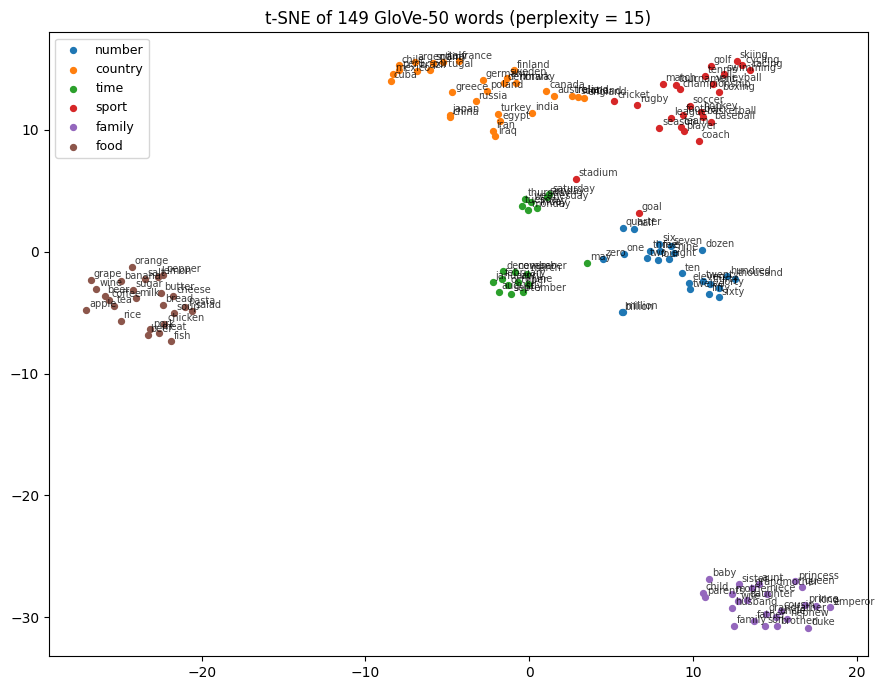

149 words plotted — related words should sit together (but see the caveat above!)


In [8]:
# ~150 everyday GloVe words from six topics
groups = {
    "number": "one two three four five six seven eight nine ten eleven twelve twenty thirty forty fifty sixty hundred thousand million billion zero dozen half quarter".split(),
    "country": "france germany italy spain portugal japan china india brazil canada mexico russia england australia egypt greece turkey poland sweden norway denmark finland ireland scotland argentina chile peru cuba iran iraq".split(),
    "time": "january february march april may june july august september october november december monday tuesday wednesday thursday friday saturday sunday".split(),
    "sport": "football soccer basketball baseball tennis golf hockey cricket rugby boxing swimming cycling skiing volleyball player team coach league season match tournament championship stadium goal racing".split(),
    "family": "mother father sister brother daughter son aunt uncle grandmother grandfather wife husband cousin nephew niece king queen prince princess duke emperor child baby family parents".split(),
    "food": "bread cheese butter milk coffee tea wine beer sugar salt pepper rice pasta soup salad meat chicken beef pork fish apple orange banana grape lemon".split(),
}
words = [w for g in groups.values() for w in g]
labels = [t for t, g in groups.items() for _ in g]

n = tsne_plot(words, labels)
print(f"{n} words plotted — related words should sit together (but see the caveat above!)")

---

## 🔬 Exercise E5 — Does cosine actually know what "similar" means? Build a benchmark.

Section 3 showed neighbour lists and invited you to nod along. That is not evidence — it's a demo with the failures cropped out. A neighbour list *always* returns five words; the question is whether the numbers behind them separate real similarity from coincidence.

**Two probe sets are provided below** — `SIMILAR_PAIRS` (words you'd call related) and `UNRELATED_PAIRS` (words you wouldn't), 10 pairs each, already checked against the tiny model's 2,000-word vocabulary. You don't need to invent them; your job is to put them to the test.

**Compute, for each space (`tiny`, `glove`):**

1. **Score every pair** with `tiny_cos` / `glove_cos`, skipping any pair a space can't handle (count how many you skipped).
2. **The average similarity of `SIMILAR_PAIRS`**, and **the average similarity of `UNRELATED_PAIRS`** — two numbers, not one.
3. **The separation**: mean(similar) − mean(unrelated). Bigger means the space distinguishes related from unrelated more sharply.
4. **The `UNRELATED_PAIRS` pair that scored highest**, and **the `SIMILAR_PAIRS` pair that scored lowest** — the two averages above hide these; they're where each space came closest to embarrassing itself.
5. Store everything in a dict called `benchmark` keyed by `"tiny"` and `"glove"`.

**Then answer below:** which space separated better, and by how much? Look at the two "worst offender" pairs you found — what does a high cosine between two unrelated words actually tell you about what the model learned?

> `in_tiny`, `tiny_cos`, `glove_cos` are all you need. No new libraries.

In [9]:
# Provided — two probe sets of everyday word pairs, and the vocabulary-coverage check.
# You don't need to invent these: the exercise is putting them to the test, not writing them.
SIMILAR_PAIRS = [
    ("oil", "gas"), ("game", "games"), ("company", "firm"), ("president", "minister"),
    ("stock", "stocks"), ("war", "military"), ("computer", "software"), ("money", "cash"),
    ("police", "court"), ("market", "markets"),
]
UNRELATED_PAIRS = [
    ("oil", "music"), ("game", "court"), ("company", "sunday"), ("president", "software"),
    ("stock", "team"), ("war", "computer"), ("music", "market"), ("police", "internet"),
    ("food", "stock"), ("car", "minister"),
]

# coverage check FIRST — a benchmark scored on 2 surviving pairs proves nothing
for name, pairs in [("similar", SIMILAR_PAIRS), ("unrelated", UNRELATED_PAIRS)]:
    missing = {w for p in pairs for w in p if not in_tiny(w)}
    print(f"{name:10} {len(pairs)} pairs, words missing from the tiny vocab: {missing or 'none'}")

similar    10 pairs, words missing from the tiny vocab: none
unrelated  10 pairs, words missing from the tiny vocab: none


In [10]:
# TODO: 1) score both groups with tiny_cos and glove_cos, skipping unscorable pairs
# TODO: 2) mean_similar and mean_unrelated, per space (two numbers, not one)
# TODO: 3) separation = mean_similar - mean_unrelated, per space
# TODO: 4) the UNRELATED_PAIRS pair with the highest score, and the SIMILAR_PAIRS pair with the lowest
# TODO: 5) build `benchmark` = {"tiny": {...}, "glove": {...}}
# HINT: tiny_cos(a, b) returns None when a word is outside the 2,000-word vocabulary
# HINT: [(s, a, b) for (a, b), s in zip(PAIRS, scores) if s is not None] drops skipped pairs


In [11]:
# Light check on YOUR benchmark (in-class = completion, not correctness)
assert set(benchmark) >= {"tiny", "glove"}, "benchmark both spaces"
required = {"mean_similar", "mean_unrelated", "separation", "top_unrelated", "bottom_similar"}
assert all(required <= set(r) for r in benchmark.values()), "missing required fields"

winner = max(benchmark, key=lambda s: benchmark[s]["separation"])
print(f"✓ E5 experiment complete: {len(SIMILAR_PAIRS)} similar + {len(UNRELATED_PAIRS)} unrelated pairs")
for space, r in benchmark.items():
    print(f"  {space:6} separation = {r['separation']:+.3f}  ({r['skipped']} pair(s) skipped)")
print(f"  → {winner} separates related from unrelated more sharply "
      f"({benchmark[winner]['separation']:+.3f})")

NameError: name 'benchmark' is not defined

**Your findings.** Which space separated better and by how much? Where did each one fail, and what does a high cosine between two unrelated words actually mean?

> TODO: your answer here (3–4 sentences)


---

## 🔬 Exercise E6 — How often does the analogy trick *actually* work?

`king − man + woman ≈ queen` is the most-quoted result in the history of word embeddings. Section 4 reproduced it, plus one more that also worked. Two successes chosen by the people writing the demo.

**A 16-analogy test set is provided below**, spanning 5 relation types (capital→country, gender, singular→plural, adjective→comparative, verb→past tense). You don't need to invent it — stop cherry-picking and measure the real hit rate.

**Compute:**

1. **Score every analogy** with `analogy(a, b, c, k=3)`: does `expected` come back **top-1**? Does it appear **anywhere in the top-3**?
2. **Overall accuracy@1 and accuracy@3**, then the same two numbers **broken down by relation type**.
3. **Every failure**, printed with what GloVe answered instead — the wrong answers are the interesting part.
4. Store per-type results in a dict called `analogy_results`.

**Then answer below:** what was the real hit rate, and which relation types worked versus failed? Look at the wrong answers — were they *random*, or wrong in a systematic way that tells you something about what the vectors encode?

> `analogy(a, b, c, k)` returns `[]` for unknown words — use lowercase, single-token words.

In [ ]:
# Provided — 16 analogies across 5 relation types.
# You don't need to invent these: the exercise is measuring the real hit rate, not building the test set.
MY_ANALOGIES = [
    # capital -> country
    ("paris", "france", "madrid", "spain", "capital"),
    ("paris", "france", "lisbon", "portugal", "capital"),
    ("paris", "france", "tokyo", "japan", "capital"),
    ("paris", "france", "cairo", "egypt", "capital"),
    # male -> female
    ("man", "king", "woman", "queen", "gender"),
    ("man", "boy", "woman", "girl", "gender"),
    ("father", "mother", "uncle", "aunt", "gender"),
    ("brother", "sister", "nephew", "niece", "gender"),
    # singular -> plural
    ("car", "cars", "book", "books", "plural"),
    ("dog", "dogs", "horse", "horses", "plural"),
    ("city", "cities", "country", "countries", "plural"),
    # adjective -> comparative
    ("big", "bigger", "small", "smaller", "comparative"),
    ("fast", "faster", "slow", "slower", "comparative"),
    ("high", "higher", "low", "lower", "comparative"),
    # verb -> past tense
    ("walk", "walked", "play", "played", "past"),
    ("go", "went", "take", "took", "past"),
]

In [ ]:
# TODO: 1) score each analogy with analogy(a, b, c, k=3): is `expected` top-1? in the top-3?
# TODO: 2) report accuracy@1 and accuracy@3 overall AND per relation type
# TODO: 3) print every failure with GloVe's actual answer
# HINT: preds = analogy(a, b, c, k=3);  got = [w for w, _ in preds]
# HINT: hit1 = got[:1] == [expected];   hit3 = expected in got


In [ ]:
# Light check on YOUR analogy benchmark (in-class = completion, not correctness)
assert len(analogy_results) >= 3, "cover at least 3 different relation types"
assert all("acc1" in r and "acc3" in r for r in analogy_results.values())

best = max(analogy_results, key=lambda r: analogy_results[r]["acc1"])
worst = min(analogy_results, key=lambda r: analogy_results[r]["acc1"])
print(f"✓ E6 experiment complete: {len(MY_ANALOGIES)} analogies across {len(analogy_results)} relation types")
print(f"  overall : acc@1 = {acc1:.0%}, acc@3 = {acc3:.0%}")
print(f"  best    : {best} ({analogy_results[best]['acc1']:.0%} @1)")
print(f"  worst   : {worst} ({analogy_results[worst]['acc1']:.0%} @1)")
print(f"  → the headline demo is {'NOT ' if acc1 < 0.9 else ''}representative "
      f"of the method's real hit rate")

**Your findings.** What was the real accuracy? Which relation types worked and which broke? Were the wrong answers random, or systematically wrong?

> TODO: your answer here (3–4 sentences)


---

## Wrap-up — what you actually did

You were handed two embedding spaces and a set of operations, and used them to produce two findings that were **not** in the notebook:

- **E5** — you replaced "look, the neighbours seem sensible" with a benchmark that *could have failed*, and measured how sharply each space separates related words from unrelated ones. That gap, not the neighbour list, is the evidence.
- **E6** — you measured the true hit rate of the most-quoted result in the field, broke it down by relation type, and looked at the wrong answers instead of hiding them.

**Concept check (discuss aloud):**

1. Two words with a **high cosine** in the tiny model may still be unrelated in meaning. What did the model actually learn about them?
2. The analogy `a : b :: c : ?` excludes $a$, $b$ and $c$ from the answers. What would happen if it didn't?
3. Your t-SNE map put two clusters far apart. Why are you not allowed to conclude those topics are unrelated?

You now have the full pipeline: text became tokens, tokens became vectors, and vectors became something you can measure. Next up: **Lesson 4**, where these pieces are assembled into a system that *generates* — a sequence-to-sequence translator. Beyond that: **Module 2 — Transformers**, where these vectors learn to look at each other.

Respuesta E5:La lista de vecinos se puede elegir; la brecha de separación no. Convertimos una impresión subjetiva en una medida que podía fallar, y por eso ese número, no los ejemplos, es la prueba.


Respuesta E6: La analogía vectorial no es una ley universal: funciona bien para relaciones estables y simétricas, pero falla en reglas gramaticales y transformaciones. La tasa real, no el ejemplo seleccionado, es lo que muestra sus límites.

Conceptos:

1 Aprendió que aparecen juntas, no que significan lo mismo. La similitud mide proximidad en el texto, no cercanía de significado. En un modelo pequeño, eso es todo lo que hay.

2 Las palabras de entrada serían siempre la respuesta principal, porque el vector resultante permanece más cerca de ellas que de cualquier otra palabra. La exclusión es necesaria para obligar al modelo a dar una palabra nueva, en lugar de repetir la que ya le diste.

3 t‑SNE sacrifica las distancias globales para preservar las relaciones locales. Por eso, la distancia entre cúmulos en el mapa no tiene significado: el algoritmo los alejó visualmente para distinguirlos, no porque lo estuvieran en verdad. Solo la cercanía entre vecinos de un mismo grupo es evidencia; la separación entre grupos es una ilusión del dibujo, no una medida de su relación.